# A/B-тест: новая версия страницы (B) против старой (A)

**Гипотеза бизнеса:** новая страница (группа **B**) повышает конверсию по сравнению со старой (группа **A**).

**Данные:** `data/ab_test.csv` - 10 000 пользователей. Поля: `group` (A/B), `converted` (0/1), `revenue`.

**Метрики:** конверсия (доля) и выручка на пользователя (ARPU).


In [5]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

df = pd.read_csv('data/ab_test.csv')
df.head()

,user_id,group,converted,revenue
0,1,A,0,0.00
1,2,B,0,0.00
2,3,B,0,0.00
3,4,A,0,0.00
4,5,A,1,76.59


In [6]:
summary = df.groupby('group').agg(
    users=('user_id', 'count'),
    conv_rate=('converted', 'mean'),
    arpu=('revenue', 'mean')
).round(4)
summary

,users,conv_rate,arpu
group,,,
A,5061,0.0935,4.6236
B,4939,0.1203,6.1629


A ~ 9,35%, B ~ 12,03%. Вопрос: разница в 2,7% - это реальный эффект новой страница или просто повезло с выборкой? \
H0 ( нулевая гипотеза ) - разницы нет, конверсии A и B равны, а наблюдаемая разница - случайность. \
H1 - разница есть, B отличается от A. \
Если p_value маленький, то такую разницу нельзя объяснить случайностью и можно отвергать H0.

In [7]:
n_A = (df['group'] == 'A').sum()
n_B = (df['group'] == 'B').sum()
conv_A = df.loc[df['group'] == 'A', 'converted'].sum()
conv_B = df.loc[df['group'] == 'B', 'converted'].sum()
p_A, p_B = conv_A / n_A, conv_B / n_B

p_pool = (conv_A + conv_B) / (n_A + n_B)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))
z = (p_B - p_A) / se
p_value = 2 * (1 - norm.cdf(abs(z)))   

print(f"Конверсия A = {p_A:.4f},  B = {p_B:.4f}")
print(f"z = {z:.3f},  p-value = {p_value:.6f}")

Конверсия A = 0.0935,  B = 0.1203
z = 4.341,  p-value = 0.000014


p_value = 0,000014 , что очень мало и ниже стандарта (0,05) --> отвергаем H0.
Вывод: новая страница повышает конверсию

In [9]:
diff = p_B - p_A
se_diff = np.sqrt(p_A*(1-p_A)/n_A + p_B*(1-p_B)/n_B)
ci_low  = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

print(f"Разница (B - A) = {diff*100:.2f} п.п.")
print(f"95% доверительный интервал: [{ci_low*100:.2f}; {ci_high*100:.2f}] п.п.")

Разница (B - A) = 2.68 п.п.
95% доверительный интервал: [1.47; 3.89] п.п.


Это значит, что с 95% уверенностью истинный прирост конверсии лежит в данном диапазоне.

In [12]:
rev_A = df.loc[df['group'] == 'A', 'revenue']
rev_B = df.loc[df['group'] == 'B', 'revenue']

t_stat, p_value_rev = stats.ttest_ind(rev_A, rev_B, equal_var=False) 

print(f"ARPU A = {rev_A.mean():.2f},  B = {rev_B.mean():.2f}")
print(f"t = {t_stat:.3f},  p-value = {p_value_rev:.6f}")

ARPU A = 4.62,  B = 6.16
t = -4.717,  p-value = 0.000002


Вывод: разница в ARPU тоже реальная - новая страница B выигрывает по обемм метрикам: и конверсия, и выручка на пользователя статистически значимо выше.

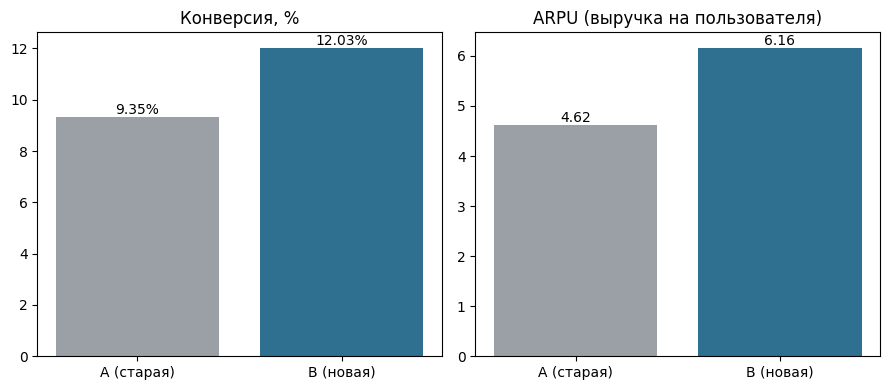

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))

ax[0].bar(['A (старая)', 'B (новая)'], [p_A*100, p_B*100], color=['#9aa0a6', '#2F6F8F'])
ax[0].set_title('Конверсия, %')
for i, v in enumerate([p_A*100, p_B*100]):
    ax[0].text(i, v + 0.1, f'{v:.2f}%', ha='center')

ax[1].bar(['A (старая)', 'B (новая)'], [rev_A.mean(), rev_B.mean()], color=['#9aa0a6', '#2F6F8F'])
ax[1].set_title('ARPU (выручка на пользователя)')
for i, v in enumerate([rev_A.mean(), rev_B.mean()]):
    ax[1].text(i, v + 0.05, f'{v:.2f}', ha='center')

plt.tight_layout()

plt.savefig('images/ab_result.png', dpi=120, bbox_inches='tight')

plt.show()

## Выводы и рекомендация

**A/B-тест, 10 000 пользователей:**

 | Метрика | A (старая) | B (новая) | p-value | Значимо? |
 |---|---|---|---|---|
 | Конверсия | 9.35% | 12.03% | 0.000014 | Да |
 | ARPU | 4.62 | 6.16 | 0.000002 | Да |

- Конверсия выросла на **+2.68 п.п.** (95% ДИ [1.47; 3.89]), ≈ **+29%**.
- Обе метрики значимо лучше у B (p < 0.001).

**Рекомендация:** выкатить версию **B** на всех пользователей.